# Fisher Information Scaling for All Pulsar Parameters with CGW Sources

This notebook computes the conditional Fisher information for **every** pulsar
timing-model parameter (not just distance/PX) and studies how it scales with
the number of continuous gravitational-wave (CGW) sources injected into the
PTA data.

We use `jax.grad(jax.grad(...))` to compute the diagonal Fisher information
$F_{ii} = -\partial^2 \ln\mathcal{L} / \partial\theta_i^2$ for each parameter
$\theta_i$, then derive the conditional Cram&#233;r-Rao bound
$\sigma_i \geq 1/\sqrt{F_{ii}}$.

See also `pta_likelihood_vs_distance.ipynb` which focuses on PX alone.

In [ ]:
from __future__ import annotations

import time

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import pint.models as pm

from jaxpint.pta.likelihood import pta_logL
from jaxpint.pta.signals.cw import CWInjector
from jaxpint.notebook_utils import (
    build_cw_injectors,
    generate_random_par,
    inject_and_build_config,
    setup_synthetic_pta,
)

# ---- Configuration ----
N_PULSARS = 5
M_CW_SOURCES = 50
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0
TOA_ERROR = 1e-8
FREQ = 1400.0
SEED = 42
M_SWEEP = [0, 1, 2, 5, 10, 20, 50]


## Generate Random Pulsars

In [ ]:
rng = np.random.default_rng(SEED)

par_strings = [
    generate_random_par(
        idx, rng,
        start_mjd=START_MJD,
        include_dm=True,
        extra_params={"EQUAD tel gbt": "0.1"},
    )
    for idx in range(N_PULSARS)
]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")


In [ ]:
synthetic = setup_synthetic_pta(
    pint_models,
    start_mjd=START_MJD, end_mjd=END_MJD,
    n_toas=N_TOAS, toa_error_s=TOA_ERROR, freq_mhz=FREQ,
)
pulsar_params_list = list(synthetic.pulsar_params_list)
timing_models = list(synthetic.timing_models)
noise_models = list(synthetic.noise_models)
base_toa_data_list = list(synthetic.toa_data_list)

for i, model in enumerate(pint_models):
    px_val = float(pulsar_params_list[i].param_value("PX"))
    f0 = float(pulsar_params_list[i].param_value("F0"))
    print(f"  Pulsar {i}: {model.PSR.value:>20s}  PX(dist)={px_val:.2f} kpc  F0={f0:.1f} Hz")

print(f"\nAll {N_PULSARS} pulsars loaded.")


## Inspect Parameter Layout

Each pulsar's `ParameterVector` contains all timing-model and noise parameters.
We will compute Fisher information for every parameter listed below.

In [4]:
pp0 = pulsar_params_list[0]
print(f"Pulsar 0 has {pp0.n_params} parameters:")
print(f"{'idx':>4s}  {'name':>12s}  {'value':>16s}  {'frozen':>6s}")
print("-" * 44)
for i, (name, frozen) in enumerate(zip(pp0.names, pp0.frozen_mask)):
    val = float(pp0.values[i])
    status = "FROZEN" if frozen else "free"
    print(f"{i:4d}  {name:>12s}  {val:+16.6e}  {status:>6s}")

param_names = list(pp0.names)
print(f"\nParameters to analyse: {param_names}")

Pulsar 0 has 13 parameters:
 idx          name             value  frozen
--------------------------------------------
   0            PX     +2.939100e+00  FROZEN
   1           RAJ     +4.862909e+00  FROZEN
   2          DECJ     -1.225496e-01  FROZEN
   3          PMRA     +0.000000e+00  FROZEN
   4         PMDEC     +0.000000e+00  FROZEN
   5            F0     +4.434392e+02  FROZEN
   6        PEPOCH     +0.000000e+00  FROZEN
   7            F1     -2.481624e-15  FROZEN
   8            DM     +1.376710e+01  FROZEN
   9         EFAC1     +1.000000e+00  FROZEN
  10        EQUAD1     +1.000000e-07  FROZEN
  11        TZRMJD     +3.201421e-10  FROZEN
  12        TZRFRQ              +inf  FROZEN

Parameters to analyse: ['PX', 'RAJ', 'DECJ', 'PMRA', 'PMDEC', 'F0', 'PEPOCH', 'F1', 'DM', 'EFAC1', 'EQUAD1', 'TZRMJD', 'TZRFRQ']


## Set Up CW Sources and Helpers

In [ ]:
all_cw_injectors, positions = build_cw_injectors(
    pint_models, n_sources=M_CW_SOURCES, rng=rng, log10_h=-12.0,
)
all_cw_injectors = list(all_cw_injectors)
print(f"Generated {M_CW_SOURCES} CW sources")


In [ ]:
def build_pta_config(M):
    """Build a (GlobalParams, pp_tuple, PTAConfig) for M injected CW sources."""
    cw_subset = tuple(all_cw_injectors[:M])
    gp, cfg = inject_and_build_config(synthetic, cw_subset)
    return gp, synthetic.pulsar_params_list, cfg


def fisher_all_params(target_pulsar, gp, pp_tuple, cfg):
    """Compute conditional Fisher info for every parameter of one pulsar."""
    target_pp = pp_tuple[target_pulsar]
    results = {}
    for name in target_pp.names:
        true_val = jnp.float64(float(target_pp.param_value(name)))

        @jax.jit
        def _eval(val, _name=name, _gp=gp, _cfg=cfg):
            mod = pp_tuple[target_pulsar].with_value(_name, val)
            pp_mod = pp_tuple[:target_pulsar] + (mod,) + pp_tuple[target_pulsar + 1:]
            return pta_logL(_gp, pp_mod, _cfg)

        F_ii = float(-jax.grad(jax.grad(_eval))(true_val))
        results[name] = F_ii
    return results


## Sweep Over Number of CW Sources

Compute Fisher information for all parameters of pulsar 0 as we increase the
number of CGW sources from 0 (baseline, no CW) to 50.

In [7]:
TARGET_PULSAR = 0
sweep_results = {}

for M in M_SWEEP:
    t0 = time.time()
    gp, pp_tuple, cfg = build_pta_config(M)
    result = fisher_all_params(TARGET_PULSAR, gp, pp_tuple, cfg)
    elapsed = time.time() - t0
    sweep_results[M] = result
    print(f"M={M:3d}  ({elapsed:.1f}s)  PX Fisher={result.get('PX', 0.0):.4e}")

print("\nDone.")

/tmp/ipykernel_33285/1138990919.py:4: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  cfg = PTAConfig(


M=  0  (222.1s)  PX Fisher=1.1243e+04


/tmp/ipykernel_33285/1138990919.py:27: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  cfg = PTAConfig(


M=  1  (256.6s)  PX Fisher=1.4523e+13
M=  2  (251.2s)  PX Fisher=5.4596e+13
M=  5  (275.0s)  PX Fisher=8.9695e+13
M= 10  (356.0s)  PX Fisher=8.1334e+13
M= 20  (493.7s)  PX Fisher=1.0246e+14
M= 50  (854.5s)  PX Fisher=3.3121e+14

Done.


/tmp/ipykernel_33285/4102486031.py:32: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


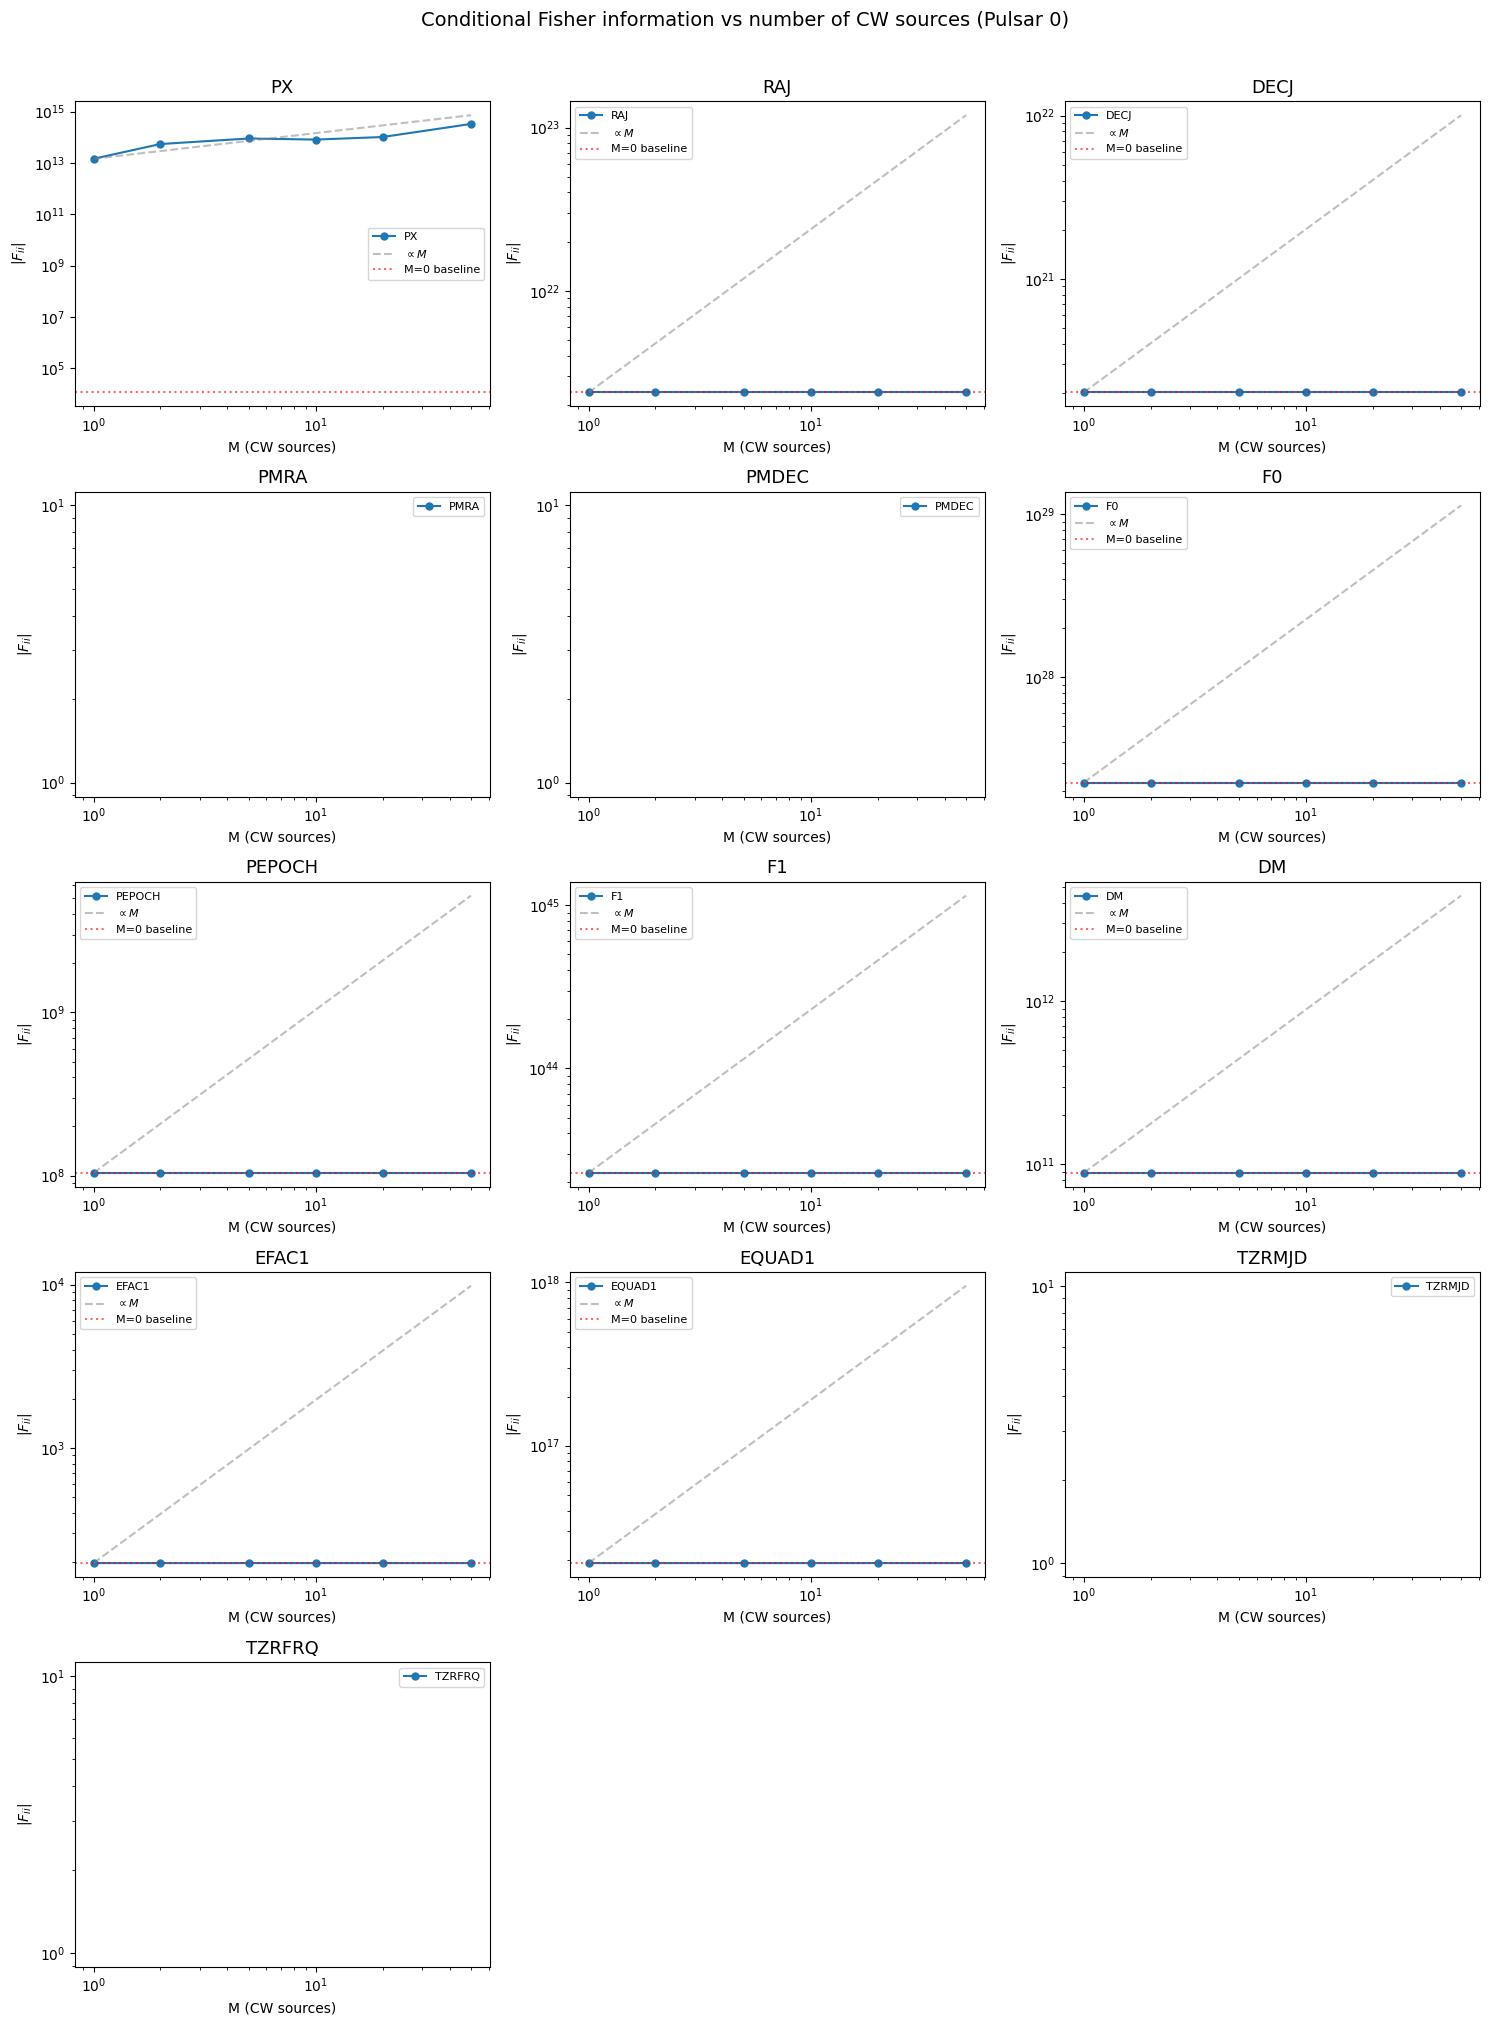

In [8]:
# Collect results into arrays for plotting
fisher_by_param = {name: np.array([sweep_results[M][name] for M in M_SWEEP])
                   for name in param_names}

# Fisher info vs M — one subplot per parameter
n_params = len(param_names)
ncols = 3
nrows = int(np.ceil(n_params / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flatten()

M_arr = np.array(M_SWEEP)
M_nonzero = M_arr[M_arr > 0]

for ax, name in zip(axes_flat, param_names):
    F_vals = fisher_by_param[name]
    F_nonzero = F_vals[M_arr > 0]

    ax.plot(M_nonzero, np.abs(F_nonzero), "o-", markersize=5, linewidth=1.5, label=name)

    # Reference: linear scaling from M=1
    if len(F_nonzero) > 0 and F_nonzero[0] != 0:
        ax.plot(M_nonzero, np.abs(F_nonzero[0]) * M_nonzero,
                "--", color="gray", alpha=0.5, label=r"$\propto M$")

    # Baseline (M=0) as horizontal line
    if F_vals[0] != 0:
        ax.axhline(np.abs(F_vals[0]), color="red", linestyle=":", alpha=0.6,
                    label=f"M=0 baseline")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("M (CW sources)")
    ax.set_ylabel(r"$|F_{ii}|$")
    ax.set_title(name, fontsize=13)
    ax.legend(fontsize=8)

# Hide unused axes
for ax in axes_flat[n_params:]:
    ax.set_visible(False)

fig.suptitle(f"Conditional Fisher information vs number of CW sources (Pulsar {TARGET_PULSAR})",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# CR bound (sigma) vs M — one subplot per parameter
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flatten()

for ax, name in zip(axes_flat, param_names):
    F_vals = fisher_by_param[name]
    sigma = np.where(F_vals > 0, 1.0 / np.sqrt(F_vals), np.nan)
    F_nonzero = F_vals[M_arr > 0]
    sigma_nonzero = sigma[M_arr > 0]

    ax.plot(M_nonzero, sigma_nonzero, "o-", markersize=5, linewidth=1.5, label=name)

    # Reference: 1/sqrt(M) scaling from M=1
    if len(sigma_nonzero) > 0 and np.isfinite(sigma_nonzero[0]):
        ax.plot(M_nonzero, sigma_nonzero[0] / np.sqrt(M_nonzero),
                "--", color="gray", alpha=0.5, label=r"$\propto 1/\sqrt{M}$")

    # Baseline (M=0)
    if np.isfinite(sigma[0]):
        ax.axhline(sigma[0], color="red", linestyle=":", alpha=0.6,
                    label=f"M=0 baseline")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("M (CW sources)")
    ax.set_ylabel(r"CR bound $\sigma_i$")
    ax.set_title(name, fontsize=13)
    ax.legend(fontsize=8)

for ax in axes_flat[n_params:]:
    ax.set_visible(False)

fig.suptitle(f"Conditional CR bound vs number of CW sources (Pulsar {TARGET_PULSAR})",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_33285/1585243907.py:7: RuntimeWarning: divide by zero encountered in divide
  sigma = np.where(F_vals > 0, 1.0 / np.sqrt(F_vals), np.nan)
/tmp/ipykernel_33285/1585243907.py:7: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.where(F_vals > 0, 1.0 / np.sqrt(F_vals), np.nan)


ValueError: Data has no positive values, and therefore cannot be log-scaled.

Error in callback <function _draw_all_if_interactive at 0x7d7ad6f42e80> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 1500x2000 with 15 Axes>

In [ ]:
# Improvement factor: sigma(M=0) / sigma(M) for each parameter
fig, ax = plt.subplots(figsize=(10, 6))

baseline = sweep_results[0]
colors = plt.cm.tab10(np.linspace(0, 1, n_params))

for name, color in zip(param_names, colors):
    F_baseline = baseline[name]
    if F_baseline <= 0:
        continue  # skip parameters with no baseline info
    sigma_baseline = 1.0 / np.sqrt(F_baseline)

    F_vals = fisher_by_param[name]
    sigma_vals = np.where(F_vals > 0, 1.0 / np.sqrt(F_vals), np.inf)
    improvement = sigma_baseline / sigma_vals

    # Only plot M > 0
    mask = M_arr > 0
    ax.plot(M_arr[mask], improvement[mask], "o-", color=color,
            markersize=5, linewidth=1.5, label=name)

ax.axhline(1.0, color="black", linestyle=":", alpha=0.3, label="no improvement")
ax.plot(M_nonzero, np.sqrt(M_nonzero), "--", color="gray", alpha=0.4,
        label=r"$\propto \sqrt{M}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of CW sources (M)", fontsize=13)
ax.set_ylabel(r"Improvement factor $\sigma(M\!=\!0)\;/\;\sigma(M)$", fontsize=13)
ax.set_title(f"Parameter constraint improvement from CW sources (Pulsar {TARGET_PULSAR})",
             fontsize=14)
ax.legend(fontsize=9, ncol=2)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

## Cross-Pulsar Comparison

Fix M=20 and compare Fisher information across all pulsars in the array.

In [ ]:
M_COMPARE = 20
gp_cmp, pp_cmp, cfg_cmp = build_pta_config(M_COMPARE)

cross_pulsar = {}
for p in range(N_PULSARS):
    t0 = time.time()
    cross_pulsar[p] = fisher_all_params(p, gp_cmp, pp_cmp, cfg_cmp)
    print(f"Pulsar {p}: {time.time() - t0:.1f}s  PX Fisher={cross_pulsar[p].get('PX', 0.0):.4e}")

# Plot grouped bar chart for CR bounds
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(n_params)
width = 0.15
offsets = np.arange(N_PULSARS) - (N_PULSARS - 1) / 2
colors_psr = plt.cm.Set2(np.linspace(0, 0.8, N_PULSARS))

for p in range(N_PULSARS):
    sigmas = []
    for name in param_names:
        F = cross_pulsar[p].get(name, 0.0)
        sigmas.append(1.0 / np.sqrt(abs(F)) if F > 0 else np.nan)
    ax.bar(x + offsets[p] * width, sigmas, width, label=f"Pulsar {p}",
           color=colors_psr[p])

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(param_names, rotation=45, ha="right")
ax.set_ylabel("CR bound", fontsize=13)
ax.set_title(f"Conditional CR bounds across pulsars (M={M_COMPARE} CW sources)", fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Dependence on Source Properties

### Fisher information vs GW frequency (all parameters, single source)

In [ ]:
template_spec = dict(all_cw_injectors[0].param_spec)

log10_fgw_grid = np.linspace(-9, -7, 40)
fisher_vs_freq = {name: [] for name in param_names}

for log10_f in log10_fgw_grid:
    spec = dict(template_spec)
    spec["log10_fgw"] = float(log10_f)

    inj = CWInjector(positions, prefix="cwfreq_", initial_values=spec)
    gp, cfg = inject_and_build_config(synthetic, (inj,))
    result = fisher_all_params(TARGET_PULSAR, gp, synthetic.pulsar_params_list, cfg)
    for name in param_names:
        fisher_vs_freq[name].append(result[name])

for name in param_names:
    fisher_vs_freq[name] = np.array(fisher_vs_freq[name])

print("Done.")

# Plot
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flatten()

for ax, name in zip(axes_flat, param_names):
    F_vals = fisher_vs_freq[name]
    ax.semilogy(log10_fgw_grid, np.abs(F_vals), "o-", markersize=4, linewidth=1.2)
    ax.set_xlabel(r"$\log_{10}(f_{\rm gw}/{\rm Hz})$")
    ax.set_ylabel(r"$|F_{ii}|$")
    ax.set_title(name)

for ax in axes_flat[n_params:]:
    ax.set_visible(False)

fig.suptitle(f"Fisher info vs GW frequency (pulsar {TARGET_PULSAR}, 1 CW source)", fontsize=14)
plt.tight_layout()
plt.show()


### Fisher information vs strain amplitude (all parameters, single source)

In [ ]:
template_spec_h = dict(all_cw_injectors[0].param_spec)

log10_h_grid = np.linspace(-15, -11, 40)
fisher_vs_h = {name: [] for name in param_names}

for log10_h in log10_h_grid:
    spec = dict(template_spec_h)
    spec["log10_h"] = float(log10_h)

    inj = CWInjector(positions, prefix="cwamp_", initial_values=spec)
    gp, cfg = inject_and_build_config(synthetic, (inj,))
    result = fisher_all_params(TARGET_PULSAR, gp, synthetic.pulsar_params_list, cfg)
    for name in param_names:
        fisher_vs_h[name].append(result[name])

for name in param_names:
    fisher_vs_h[name] = np.array(fisher_vs_h[name])

print("Done.")

# Plot
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes_flat = axes.flatten()

for ax, name in zip(axes_flat, param_names):
    F_vals = fisher_vs_h[name]
    ax.semilogy(log10_h_grid, np.abs(F_vals), "o-", markersize=4, linewidth=1.2)
    # h^2 reference
    h_ref = 10.0 ** log10_h_grid
    if len(F_vals) > 0 and F_vals[len(F_vals)//2] != 0:
        h0 = 10.0 ** log10_h_grid[len(log10_h_grid)//2]
        F0 = F_vals[len(log10_h_grid)//2]
        ax.semilogy(log10_h_grid, np.abs(F0) * (h_ref / h0) ** 2, "--", color="gray", alpha=0.5, label=r"$\propto h^2$")
    ax.set_xlabel(r"$\log_{10}(h)$")
    ax.set_ylabel(r"$|F_{ii}|$")
    ax.set_title(name)
    ax.legend(fontsize=8)

for ax in axes_flat[n_params:]:
    ax.set_visible(False)

fig.suptitle(f"Fisher info vs strain amplitude (pulsar {TARGET_PULSAR}, 1 CW source)", fontsize=14)
plt.tight_layout()
plt.show()


## Summary

In [ ]:
# Summary table
print(f"{'Parameter':>12s} | {'F(M=0)':>12s} | {'F(M=50)':>12s} | "
      f"{'sigma(M=0)':>12s} | {'sigma(M=50)':>12s} | {'Improvement':>12s}")
print("-" * 82)

for name in param_names:
    F0 = sweep_results[0][name]
    F50 = sweep_results[50][name]
    s0 = 1.0 / np.sqrt(abs(F0)) if F0 > 0 else np.inf
    s50 = 1.0 / np.sqrt(abs(F50)) if F50 > 0 else np.inf
    imp = s0 / s50 if np.isfinite(s0) and s50 > 0 else np.nan
    print(f"{name:>12s} | {F0:>12.4e} | {F50:>12.4e} | "
          f"{s0:>12.4e} | {s50:>12.4e} | {imp:>12.2f}x")